# Chapter 5: Text Clustering and Topic Modeling

In [1]:
!pip  install bertopic datasets openai datamapplot bertopic

  Using cached bertopic-0.17.4-py3-none-any.whl.metadata (24 kB)
  Using cached datamapplot-0.7.3-py3-none-any.whl.metadata (7.9 kB)
  Using cached colorspacious-1.1.2-py2.py3-none-any.whl.metadata (3.6 kB)
  Using cached datashader-0.19.1-py3-none-any.whl.metadata (8.0 kB)
  Using cached pylabeladjust-0.1.13-py3-none-any.whl.metadata (8.2 kB)
  Using cached dask-2026.7.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached lz4-4.4.5-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (3.8 kB)
  Using cached pyct-0.6.0-py3-none-any.whl.metadata (7.2 kB)
  Using cached distributed-2026.7.1-py3-none-any.whl.metadata (3.4 kB)
Using cached bertopic-0.17.4-py3-none-any.whl (154 kB)
Using cached datamapplot-0.7.3-py3-none-any.whl (350 kB)
Using cached colorspacious-1.1.2-py2.py3-none-any.whl (37 kB)
Using cached dask-2026.7.1-py3-none-any.whl (1.5 MB)
Using cached datashader-0.19.1-py3-none-any.whl (10.7 MB)
Using cached pylabeladjust-0.1.13-py3-none-any.wh

# ArXiv Articles: Computation and Language

In [2]:
# Load data from huggingface
from datasets import load_dataset
dataset = load_dataset("maartengr/arxiv_nlp")["train"]

# Extract metadata
abstracts = list(dataset["Abstracts"])
titles = list(dataset["Titles"])

# A Common Pipeline for Text Clustering

## 1. Embedding Documents

In [3]:
from sentence_transformers import SentenceTransformer

# Create an embedding for each abstract
embedding_model = SentenceTransformer('thenlper/gte-small')
embeddings = embedding_model.encode(abstracts, show_progress_bar=True)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: thenlper/gte-small
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/1405 [00:00<?, ?it/s]

In [4]:
# Check the dimensions of the resulting embeddings
embeddings.shape

(44949, 384)

## 2. Reducing the Dimensionality of Embeddings

In [5]:
from umap import UMAP

# We reduce the input embeddings from 384 dimenions to 5 dimenions
umap_model = UMAP(
    n_components=5, min_dist=0.0, metric='cosine', random_state=42
)
reduced_embeddings = umap_model.fit_transform(embeddings)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


## 3. Cluster the Reduced Embeddings

In [6]:
from hdbscan import HDBSCAN

# We fit the model and extract the clusters
hdbscan_model = HDBSCAN(
    min_cluster_size=50, metric='euclidean', cluster_selection_method='eom'
).fit(reduced_embeddings)
clusters = hdbscan_model.labels_

# How many clusters did we generate?
len(set(clusters))

159

## Inspecting the Clusters

In [7]:
import numpy as np

# Print first three documents in cluster 0
cluster = 0
for index in np.where(clusters==cluster)[0][:3]:
    print(abstracts[index][:300] + "... \n")

  This works aims to design a statistical machine translation from English text
to American Sign Language (ASL). The system is based on Moses tool with some
modifications and the results are synthesized through a 3D avatar for
interpretation. First, we translate the input text to gloss, a written fo... 

  Researches on signed languages still strongly dissociate lin- guistic issues
related on phonological and phonetic aspects, and gesture studies for
recognition and synthesis purposes. This paper focuses on the imbrication of
motion and meaning for the analysis, synthesis and evaluation of sign lang... 

  Modern computational linguistic software cannot produce important aspects of
sign language translation. Using some researches we deduce that the majority of
automatic sign language translation systems ignore many aspects when they
generate animation; therefore the interpretation lost the truth inf... 



In [8]:
import pandas as pd

# Reduce 384-dimensional embeddings to 2 dimensions for easier visualization
reduced_embeddings = UMAP(
    n_components=2, min_dist=0.0, metric='cosine', random_state=42
).fit_transform(embeddings)

# Create dataframe
df = pd.DataFrame(reduced_embeddings, columns=["x", "y"])
df["title"] = titles
df["cluster"] = [str(c) for c in clusters]

# Select outliers and non-outliers (clusters)
clusters_df = df.loc[df.cluster != "-1", :]
outliers_df = df.loc[df.cluster == "-1", :]

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(np.float64(-9.041299676895141),
 np.float64(11.615294313430786),
 np.float64(-7.6163016080856325),
 np.float64(11.084579062461852))

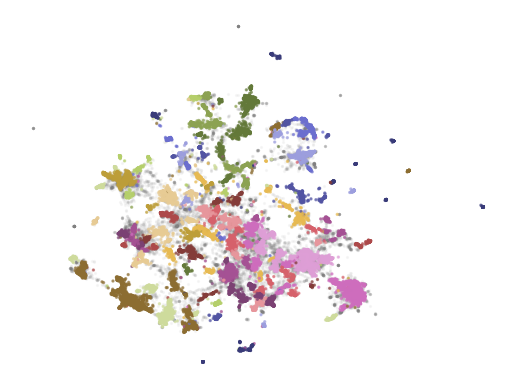

In [9]:
import matplotlib.pyplot as plt

# Plot outliers and non-outliers seperately
plt.scatter(outliers_df.x, outliers_df.y, alpha=0.05, s=2, c="grey")
plt.scatter(
    clusters_df.x, clusters_df.y, c=clusters_df.cluster.astype(int),
    alpha=0.6, s=2, cmap='tab20b'
)
plt.axis('off')
# plt.savefig("matplotlib.png", dpi=300)  # Uncomment to save the graph as a .png

# From Text Clustering to Topic Modeling

## BERTopic: A Modular Topic Modeling Framework

In [10]:
from bertopic import BERTopic

# Train our model with our previously defined models
topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    verbose=True
).fit(abstracts, embeddings)

2026-08-15 10:07:49,217 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-08-15 10:08:35,756 - BERTopic - Dimensionality - Completed ✓
2026-08-15 10:08:35,758 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-08-15 10:08:37,228 - BERTopic - Cluster - Completed ✓
2026-08-15 10:08:37,243 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-08-15 10:08:41,011 - BERTopic - Representation - Completed ✓


In [11]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,15538,-1_the_of_and_to,"[the, of, and, to, in, we, for, that, language...",[ Learning to construct text representations ...
1,0,1587,0_speech_asr_recognition_end,"[speech, asr, recognition, end, acoustic, wer,...",[ Recent advances in text-to-speech (TTS) led...
2,1,1479,1_medical_clinical_biomedical_patient,"[medical, clinical, biomedical, patient, healt...",[ A common practice in the medical industry i...
3,2,1069,2_translation_nmt_machine_bleu,"[translation, nmt, machine, bleu, neural, engl...",[ The quality of machine translation is rapid...
4,3,837,3_hate_offensive_speech_detection,"[hate, offensive, speech, detection, toxic, so...",[ With growing role of social media in shapin...
...,...,...,...,...,...
154,153,54,153_counseling_mental_therapy_health,"[counseling, mental, therapy, health, psychoth...",[ Mental health care poses an increasingly se...
155,154,52,154_backdoor_attacks_attack_triggers,"[backdoor, attacks, attack, triggers, poisoned...",[ Deep neural networks (DNNs) and natural lan...
156,155,52,155_gans_gan_adversarial_generation,"[gans, gan, adversarial, generation, generativ...",[ Text generation is of particular interest i...
157,156,51,156_temporal_events_event_timeml,"[temporal, events, event, timeml, relations, r...",[ Temporal relation extraction models have th...


In [12]:
topic_model.get_topic(0)

[('speech', np.float64(0.028533409123771385)),
 ('asr', np.float64(0.019138833922540077)),
 ('recognition', np.float64(0.013909133719155576)),
 ('end', np.float64(0.010621429434304063)),
 ('acoustic', np.float64(0.010460956236705904)),
 ('wer', np.float64(0.007447408821110592)),
 ('speaker', np.float64(0.0073356609562662605)),
 ('error', np.float64(0.006711808807312123)),
 ('ctc', np.float64(0.006453412080461576)),
 ('training', np.float64(0.0064466744613668105))]

In [13]:
topic_model.find_topics("topic modeling")

([25, -1, 1, 46, 39],
 [np.float64(0.9544818776383237),
  np.float64(0.9115890889009828),
  np.float64(0.9082214517245877),
  np.float64(0.9073075009451413),
  np.float64(0.9049991993776167)])

In [14]:
topic_model.get_topic(22)

[('attention', np.float64(0.03338783167162634)),
 ('transformer', np.float64(0.026044416462860417)),
 ('transformers', np.float64(0.01629727171337091)),
 ('self', np.float64(0.011231870914183944)),
 ('heads', np.float64(0.00973677067231886)),
 ('head', np.float64(0.009331423482875849)),
 ('memory', np.float64(0.008790051066581806)),
 ('long', np.float64(0.008146386089631596)),
 ('tokens', np.float64(0.007622467768719387)),
 ('layer', np.float64(0.007567990795637122))]

In [ ]:
topic_model.topics_[titles.index('BERTopic: Neural topic modeling with a class-based TF-IDF procedure')]

### Visualisation

In [17]:
# Visualize topics and documents
fig = topic_model.visualize_documents(
    titles,
    reduced_embeddings=reduced_embeddings,
    width=1200,
    hide_annotations=True
)

# Update fonts of legend for easier visualization
fig.update_layout(font=dict(size=16))


In [16]:
# Visualize barchart with ranked keywords
topic_model.visualize_barchart()

# Visualize relationships between topics
topic_model.visualize_heatmap(n_clusters=30)

# Visualize the potential hierarchical structure of topics
topic_model.visualize_hierarchy()